In [89]:
import pandas as pd

In [90]:
fake = pd.read_csv("../data/Fake.csv")

In [91]:

true = pd.read_csv("../data/True.csv")

In [92]:
fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [93]:
true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [94]:
print("Fake news: ", fake.shape[0])
print("True news: ", true.shape[0])


Fake news:  23481
True news:  21417


In [95]:
print(fake.columns)
print(true.columns)

Index(['title', 'text', 'subject', 'date'], dtype='str')
Index(['title', 'text', 'subject', 'date'], dtype='str')


In [96]:
print("Fake:")
print(fake.isnull().sum())

Fake:
title      0
text       0
subject    0
date       0
dtype: int64


In [97]:
print("\nReal:")
print(true.isnull().sum())


Real:
title      0
text       0
subject    0
date       0
dtype: int64


In [98]:
print("Fake duplicates: ", fake.duplicated().sum())
print("True duplicates: ", true.duplicated().sum())

Fake duplicates:  3
True duplicates:  206


In [99]:
fake["label"] = 0
true["label"] = 1

In [100]:
fake.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [101]:
true.head()

,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1


In [102]:
data = pd.concat([fake, true], ignore_index=True)

In [103]:
print(data.shape)

(44898, 5)


In [104]:
print(data["label"].value_counts())

label
0    23481
1    21417
Name: count, dtype: int64


In [105]:
data = data.drop_duplicates()

In [106]:
print(data["label"].value_counts())



label
0    23478
1    21211
Name: count, dtype: int64


In [107]:
data= data.sample(frac=1, random_state=42).reset_index(drop=True)

In [108]:
data.head()

,title,text,subject,date,label
0,WOW! LEFTIST LIBRARIAN REJECTS Shipment Of Chi...,"A school librarian in Cambridge, Massachusetts...",left-news,"Sep 28, 2017",0
1,Kenya opposition leader calls for calm in slum...,NAIROBI (Reuters) - Kenyan opposition leader R...,worldnews,"October 29, 2017",1
2,Egypt rejects U.S. decision to move its embass...,CAIRO (Reuters) - Egypt rejected the U.S. deci...,worldnews,"December 6, 2017",1
3,(AUDIO)NATION OF ISLAM LEADER FARRAKHAN: “WE W...,After a recent speech given by Minister Louis ...,left-news,"May 8, 2015",0
4,Trump Rally Nearly Turns Into A Full-Blown Ra...,Tensions ran high outside of a campaign rally ...,News,"March 11, 2016",0


In [109]:
print(data.shape)
print(data["label"].value_counts())
print(data.head())

(44689, 5)
label
0    23478
1    21211
Name: count, dtype: int64
                                               title  \
0  WOW! LEFTIST LIBRARIAN REJECTS Shipment Of Chi...   
1  Kenya opposition leader calls for calm in slum...   
2  Egypt rejects U.S. decision to move its embass...   
3  (AUDIO)NATION OF ISLAM LEADER FARRAKHAN: “WE W...   
4   Trump Rally Nearly Turns Into A Full-Blown Ra...   

                                                text    subject  \
0  A school librarian in Cambridge, Massachusetts...  left-news   
1  NAIROBI (Reuters) - Kenyan opposition leader R...  worldnews   
2  CAIRO (Reuters) - Egypt rejected the U.S. deci...  worldnews   
3  After a recent speech given by Minister Louis ...  left-news   
4  Tensions ran high outside of a campaign rally ...       News   

                date  label  
0       Sep 28, 2017      0  
1  October 29, 2017       1  
2  December 6, 2017       1  
3        May 8, 2015      0  
4     March 11, 2016      0  


In [110]:
data["content"] = data["title"] + " " + data["text"]

In [111]:
data[["title", "text", "content", "label"]].head()

,title,text,content,label
0,WOW! LEFTIST LIBRARIAN REJECTS Shipment Of Chi...,"A school librarian in Cambridge, Massachusetts...",WOW! LEFTIST LIBRARIAN REJECTS Shipment Of Chi...,0
1,Kenya opposition leader calls for calm in slum...,NAIROBI (Reuters) - Kenyan opposition leader R...,Kenya opposition leader calls for calm in slum...,1
2,Egypt rejects U.S. decision to move its embass...,CAIRO (Reuters) - Egypt rejected the U.S. deci...,Egypt rejects U.S. decision to move its embass...,1
3,(AUDIO)NATION OF ISLAM LEADER FARRAKHAN: “WE W...,After a recent speech given by Minister Louis ...,(AUDIO)NATION OF ISLAM LEADER FARRAKHAN: “WE W...,0
4,Trump Rally Nearly Turns Into A Full-Blown Ra...,Tensions ran high outside of a campaign rally ...,Trump Rally Nearly Turns Into A Full-Blown Ra...,0


In [112]:
data["content_length"] = data["content"].str.len()

In [113]:
print(data["content_length"].describe())

count    44689.000000
mean      2548.274005
std       2174.594406
min         31.000000
25%       1314.000000
50%       2268.000000
75%       3186.000000
max      51893.000000
Name: content_length, dtype: float64


In [114]:
data.groupby("label")["content_length"].mean()


label
0    2642.749936
1    2443.700627
Name: content_length, dtype: float64

In [115]:
data["content_length"].describe()

count    44689.000000
mean      2548.274005
std       2174.594406
min         31.000000
25%       1314.000000
50%       2268.000000
75%       3186.000000
max      51893.000000
Name: content_length, dtype: float64

In [116]:
data.nsmallest(10, "content_length")[["title", "content_length"]]

,title,content_length
3815,LIVE FEED: INAUGURATION 2017!,31
41623,Graphic: Supreme Court roundup,32
12050,WATCH Life Accordion To Trump! [VIDEO],40
4251,"YES, OBAMA…There Is A Magic Wand! [Video]",43
11060,BEST TWEET OF THE WEEK: “Hillary For Sale!”,45
1263,WHERE’S HILLARY? CLINTON SPOTTED Dining Alone,47
2683,TWEET OF THE DAY: Hillary…The Price Of Failure,48
10285,(VIDEO) LIBERAL PUNDIT: OBAMA WORST POTUS EVER,48
23329,IT’S NOT A “MUSLIM BAN” You Big Dummies! [VIDEO],50
12265,Judge Napolitano Slams SCOTUS Ruling on Obamacare,51


In [117]:
data.nlargest(10, "content_length")[["title", "content_length"]]

,title,content_length
2040,MEDIA TRIPWIRE? Ping Pong Pizza Conspiracy Pro...,51893
26948,MEDIA TRIPWIRE? Ping Pong Pizza Conspiracy Pro...,51893
4451,ANTI-AMERICAN GEORGE SOROS Locks Arms With NFL...,49766
14467,ANTI-AMERICAN GEORGE SOROS Locks Arms With NFL...,49766
32504,The Las Vegas Mass Shooting – More to the Stor...,48904
34509,The Las Vegas Mass Shooting – More to the Stor...,48904
29876,WOW! AMERICA IS UNDER ATTACK By These 187 Orga...,47048
37284,WOW! AMERICA IS UNDER ATTACK By These 187 Orga...,47048
9438,"CULT CRIMES, MASS SHOOTINGS & MEDIA MIND CONTR...",45004
36184,"CULT CRIMES, MASS SHOOTINGS & MEDIA MIND CONTR...",45004


In [118]:
data["content_length"].idxmax()


2040

In [119]:
data.loc[2040, "content_length"]

np.int64(51893)

In [120]:
data.loc[2040, "title"]

'MEDIA TRIPWIRE? Ping Pong Pizza Conspiracy Propels Internet Censorship Amid ‘Fake News’ Witch-Hunt'

In [121]:
data["content_length"].idxmax()

2040

In [122]:
data.loc[2040, "content_length"]

np.int64(51893)

In [123]:
print(data.loc[2040, "text"][:3000])

 Funny how secrets travel. I d start to believe, if I were to bleed.    Lyrics written by David Bowie from the album OutsideShawn Helton 21st Century Wire In the days before the US presidential election in November 2016, Wikileaks revealed a new string of emails connected to Hillary Clinton s 2016 campaign chairman, John Podesta. Online interpretations of the leaked Podesta email exchanges subsequently led to a digital firestorm on social media, producing an intense conspiratorial  open source investigation  still in search of its smoking gun. However, the phenomenon now known by its hashtag #Pizzagate has since set a number of tertiary events into motion. Is there a real story hidden amongst the debris of this online explosion?Is it possible that  open source investigators  were being led into a virtual cul-de-sac and thus missing the real story?More importantly, could people be playing into the hands of the very establishment they seek to depose?Let s investigate   SHOCK & AWE    Ove

In [124]:
import matplotlib.pyplot as plt

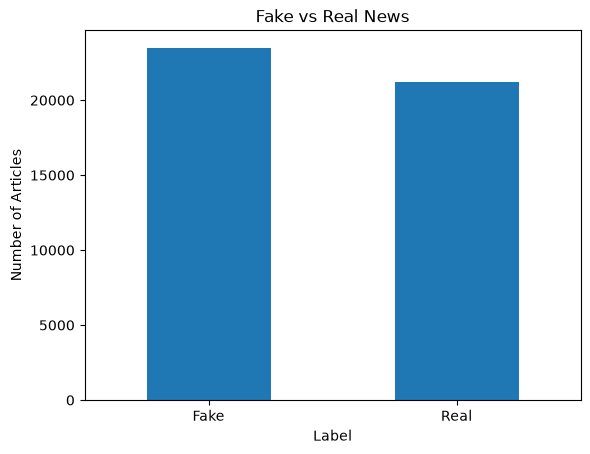

In [125]:
data["label"].value_counts().sort_index().plot(kind="bar")

plt.title("Fake vs Real News")
plt.xlabel("Label")
plt.ylabel("Number of Articles")
plt.xticks([0, 1], ["Fake", "Real"], rotation=0)

plt.show()

In [126]:
data["subject"].value_counts()

subject
politicsNews       11220
worldnews           9991
News                9050
politics            6838
left-news           4459
Government News     1570
US_News              783
Middle-east          778
Name: count, dtype: int64

In [127]:
data["content"] = data["title"] + " " + data["text"]

In [128]:
data[["title", "text", "content"]].head(2)

,title,text,content
0,WOW! LEFTIST LIBRARIAN REJECTS Shipment Of Chi...,"A school librarian in Cambridge, Massachusetts...",WOW! LEFTIST LIBRARIAN REJECTS Shipment Of Chi...
1,Kenya opposition leader calls for calm in slum...,NAIROBI (Reuters) - Kenyan opposition leader R...,Kenya opposition leader calls for calm in slum...


In [129]:
data["content"].str.strip().eq("").sum()

np.int64(0)

In [130]:
data["clean_content"] = data["content"].copy()

In [131]:
data["clean_content"] = data["clean_content"].str.lower()

In [132]:
data["clean_content"].head(2)

0    wow! leftist librarian rejects shipment of chi...
1    kenya opposition leader calls for calm in slum...
Name: clean_content, dtype: str

In [133]:
import re

In [134]:
data["clean_content"] = data["clean_content"].str.replace(r"http\S+|www\S+|https\S+", "", regex=True)

In [135]:
data["clean_content"].str.contains(r"http\S+|www\S+|https\S+", regex=True).sum()

np.int64(0)

In [136]:
data["clean_content"] = data["clean_content"].str.replace(r"http\S+|www\S+|https\S+", "", regex=True).str.strip()

In [137]:
data["clean_content"].head(2)

0    wow! leftist librarian rejects shipment of chi...
1    kenya opposition leader calls for calm in slum...
Name: clean_content, dtype: str

In [138]:
(data["clean_content"].str.len() == 0).sum()

np.int64(9)

In [139]:
empty_rows = data[data["clean_content"].str.len() == 0]

In [140]:
empty_rows[["title", "text", "label"]]

,title,text,label
97,https://fedup.wpengine.com/wp-content/uploads/...,https://fedup.wpengine.com/wp-content/uploads/...,0
4945,https://100percentfedup.com/12-yr-old-black-co...,https://100percentfedup.com/12-yr-old-black-co...,0
10698,https://100percentfedup.com/served-roy-moore-v...,https://100percentfedup.com/served-roy-moore-v...,0
15848,https://fedup.wpengine.com/wp-content/uploads/...,https://fedup.wpengine.com/wp-content/uploads/...,0
20699,https://fedup.wpengine.com/wp-content/uploads/...,https://fedup.wpengine.com/wp-content/uploads/...,0
25972,https://fedup.wpengine.com/wp-content/uploads/...,https://fedup.wpengine.com/wp-content/uploads/...,0
35525,https://fedup.wpengine.com/wp-content/uploads/...,https://fedup.wpengine.com/wp-content/uploads/...,0
42764,https://100percentfedup.com/video-hillary-aske...,https://100percentfedup.com/video-hillary-aske...,0
44395,https://fedup.wpengine.com/wp-content/uploads/...,https://fedup.wpengine.com/wp-content/uploads/...,0


In [141]:
empty_rows["label"].value_counts()

label
0    9
Name: count, dtype: int64

In [142]:
data = data[data["clean_content"].str.len() > 0].copy()

In [143]:
print(data.shape)

(44680, 8)


In [144]:
print((data["clean_content"].str.len() == 0).sum())

0


In [145]:
print(data["label"].value_counts())

label
0    23469
1    21211
Name: count, dtype: int64


In [146]:
import nltk
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to C:\Users\Mohamed
[nltk_data]     suhail\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [147]:
from nltk.corpus import stopwords


In [148]:
stop_words = set(stopwords.words("english"))

In [149]:
print(list(stop_words)[:20])

['at', 'does', 'for', 'off', 'most', "wouldn't", 'some', 'my', "mightn't", 'ours', 'mustn', 'be', 'couldn', 'to', 'into', "you're", 'can', 'him', 'those', "he'll"]


In [150]:
from sklearn.feature_extraction.text import CountVectorizer

In [151]:
vectorizer = CountVectorizer(stop_words="english",max_features=20)

In [152]:
word_matrix = vectorizer.fit_transform(data["clean_content"])

In [153]:
words_counts = word_matrix.sum(axis=0)

In [154]:
words = vectorizer.get_feature_names_out()

In [155]:
frequency = pd.DataFrame({
    "words" : words,
    "count" : words_counts.A1
}).sort_values("count",ascending=False)

In [156]:
frequency

,words,count
16,trump,148239
12,said,131837
9,president,57251
8,people,42275
13,state,35388
6,new,32927
7,obama,31370
0,clinton,30422
3,house,29604
11,reuters,29260


In [157]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [158]:
vectorizer.fit_transform(data["clean_content"])


<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 317607 stored elements and shape (44680, 20)>

In [159]:
x = data["clean_content"]
y = data["label"]

In [160]:
from sklearn.model_selection import train_test_split

In [161]:
x_train,x_test,y_train,y_test = train_test_split(x, y, test_size=0.2, random_state=42,stratify=y) 

In [162]:
print("Training samples:", len(x_train))
print("Testing samples:", len(x_test))

Training samples: 35744
Testing samples: 8936


In [163]:
print(y_train.value_counts(normalize=True))

label
0    0.525263
1    0.474737
Name: proportion, dtype: float64


In [164]:
print(y_test.value_counts(normalize=True))

label
0    0.525291
1    0.474709
Name: proportion, dtype: float64


In [165]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [166]:
tfidf = TfidfVectorizer(max_features=50000,ngram_range=(1,2),min_df=2,max_df=0.95)

In [167]:
x_train_tfidf = tfidf.fit_transform(x_train)
x_test_tfidf = tfidf.transform(x_test)

In [168]:
print("Training TF-IDF shape:",x_train_tfidf.shape)
print("Testing TF-IDF shape:",x_test_tfidf.shape)

Training TF-IDF shape: (35744, 50000)
Testing TF-IDF shape: (8936, 50000)


In [169]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(x_train_tfidf,y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [170]:
y_pred = model.predict(x_test_tfidf)

In [171]:
print(y_pred[:20])

[1 1 1 0 1 1 1 0 0 1 0 0 1 1 0 1 0 0 0 0]


In [172]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
accuracy = accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)
print(classification_report(y_test,y_pred))

Accuracy: 0.9883616830796778
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4694
           1       0.99      0.99      0.99      4242

    accuracy                           0.99      8936
   macro avg       0.99      0.99      0.99      8936
weighted avg       0.99      0.99      0.99      8936



In [173]:
cm = confusion_matrix(y_test,y_pred)
print(cm)

[[4638   56]
 [  48 4194]]


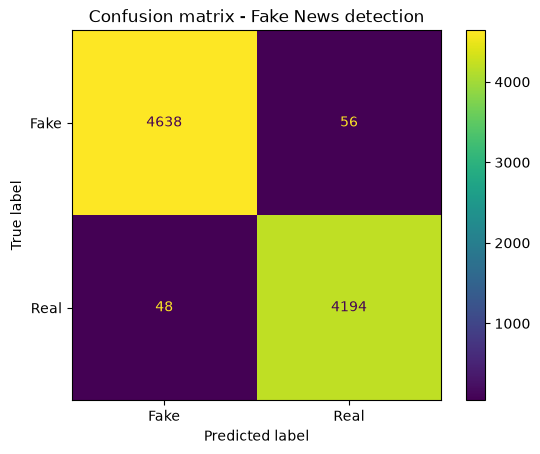

In [174]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ["Fake", "Real"]).plot()
plt.title("Confusion matrix - Fake News detection")
plt.show()

In [175]:
import joblib
joblib.dump(model, "fake_news_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")



['tfidf_vectorizer.pkl']